In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data/spam.csv", encoding="latin-1")

In [4]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

In [5]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [7]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [8]:
print("Spam messages:")
df[df["label"] == "spam"].head()

Spam messages:


,label,message
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
5,spam,FreeMsg Hey there darling it's been 3 week's n...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...
11,spam,"SIX chances to win CASH! From 100 to 20,000 po..."


In [9]:
print("Ham messages:")
df[df["label"] == "ham"].head()

Ham messages:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
6,ham,Even my brother is not like to speak with me. ...


In [10]:
df["length"] = df["message"].apply(len)

In [11]:
df.head()

,label,message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [12]:
df["length"].describe()

count    5572.000000
mean       80.118808
std        59.690841
min         2.000000
25%        36.000000
50%        61.000000
75%       121.000000
max       910.000000
Name: length, dtype: float64

In [13]:
df.groupby("label")["length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.023627,58.016023,2.0,33.0,52.0,92.0,910.0
spam,747.0,138.866131,29.183082,13.0,132.5,149.0,157.0,224.0


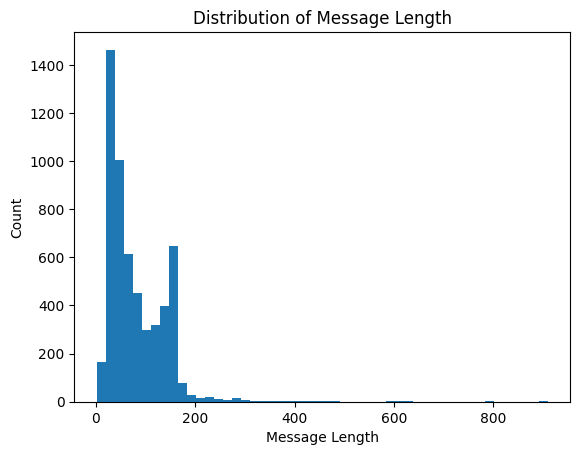

In [14]:
plt.hist(df["length"], bins=50)
plt.xlabel("Message Length")
plt.ylabel("Count")
plt.title("Distribution of Message Length")
plt.show()

In [15]:
import nltk

nltk.download("stopwords")
nltk.download("punkt")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\and98\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\and98\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [16]:
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [17]:
message = "Congratulations! You have won a FREE prize."

tokens = word_tokenize(message)

print(tokens)

LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - 'C:\\Users\\and98/nltk_data'
    - 'c:\\Users\\and98\\AppData\\Local\\Programs\\Python\\Python39\\nltk_data'
    - 'c:\\Users\\and98\\AppData\\Local\\Programs\\Python\\Python39\\share\\nltk_data'
    - 'c:\\Users\\and98\\AppData\\Local\\Programs\\Python\\Python39\\lib\\nltk_data'
    - 'C:\\Users\\and98\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [18]:
import nltk
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\and98\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [19]:
message = "Congratulations! You have won a FREE prize."

tokens = word_tokenize(message)
print(tokens)

['Congratulations', '!', 'You', 'have', 'won', 'a', 'FREE', 'prize', '.']


In [24]:
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

def clean_text (text):
    text = text.lower()
    words = word_tokenize(text)
    words = [word for word in words if word not in string.punctuation]
    words = [word for word in words if word not in stopwords.words("english")]
    return words

In [ ]:
message = "Congratulations! You have won a FREE prize."

print(clean_text(message))

['congratulations', 'free', 'prize']


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [27]:
tfidf = TfidfVectorizer()

In [28]:
X = tfidf.fit_transform(df["message"])

In [29]:
print(type(X))

<class 'scipy.sparse._csr.csr_matrix'>


In [30]:
print(X.shape)

(5572, 8672)


In [31]:
df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

In [32]:
df.head()

,label,message,length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [33]:
y = df["label"]